In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split   

In [2]:
df = pd.read_csv('datasets/iris.csv') 
df.drop(columns=['Id'], inplace=True)  
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [4]:
# removing prefix
df['Species'] = df['Species'].str.replace('Iris-', '')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df['Species'].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

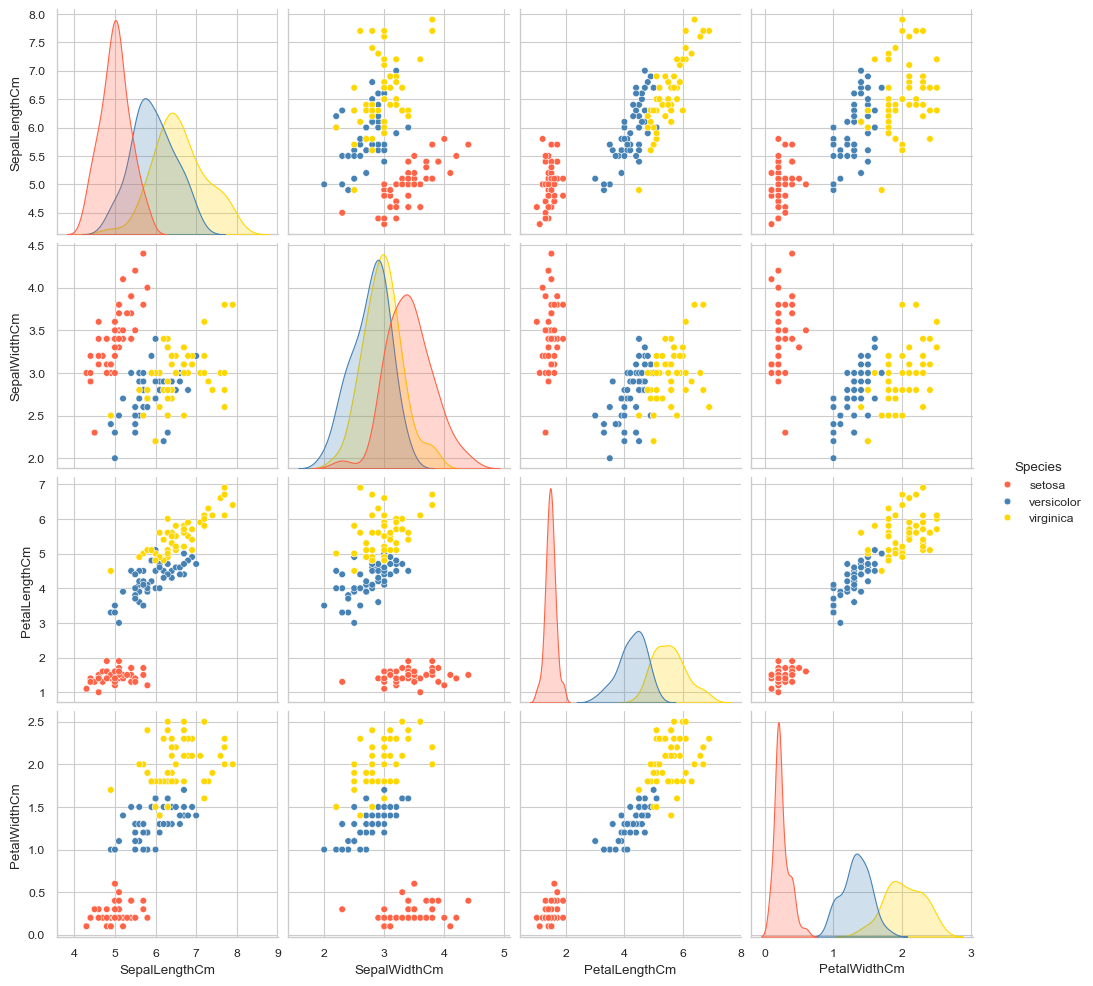

In [6]:
custom_palette = sns.color_palette(["#FF6347", "#4682B4", "#FFD700", "#6A5ACD"])

sns.set_theme(style="whitegrid", context='paper' ,palette=custom_palette)
sns.pairplot(df, hue='Species', height=2.5)
plt.show()

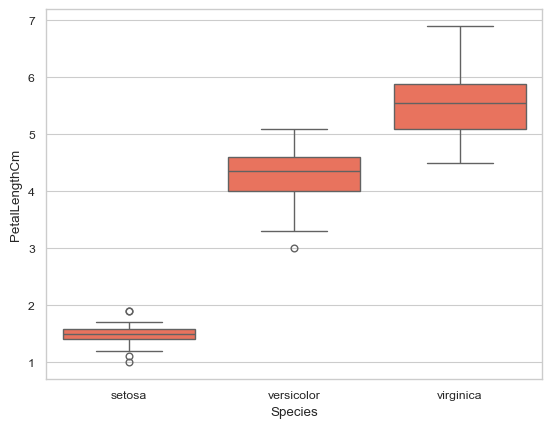

In [7]:
sns.boxplot(x='Species', y='PetalLengthCm', data=df)
plt.show()  

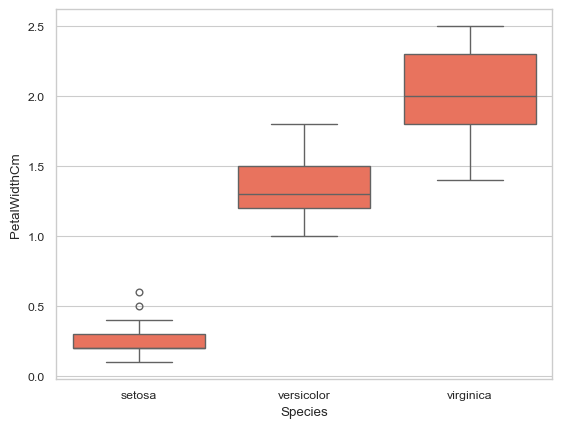

In [8]:
sns.boxplot(x='Species', y='PetalWidthCm', data=df)
plt.show()

In [10]:
# splitting input data
x = df.drop(columns=['Species'])
y = df['Species']

In [11]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
# using OVR method
lr = LogisticRegression(multi_class='ovr')
lr.fit(x_train, y_train)

c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [14]:
lr.score(x_test, y_test)*100

96.66666666666667

In [15]:
# multinomial method
lr1 = LogisticRegression(multi_class='multinomial')
lr1.fit(x_train, y_train)

c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [16]:
lr1.score(x_test, y_test)*100

100.0

In [ ]:
# we can use the direct method instead of using OVR and multinomial, it will give results same as OVR